In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import kagglehub


In [10]:
# !pip install segmentation-models-pytorch
kagglehub.login()
path = kagglehub.competition_download('severstal-steel-defect-detection')

100%|██████████| 1.57G/1.57G [00:19<00:00, 88.5MB/s]

Extracting files...


In [11]:
def encoded_pixels_to_masks(fname: str, df: pd.DataFrame):
    fname_df = df[df['ImageId'] == fname]
    masks = np.zeros((256 * 1600, 4), dtype=int) # float32 is V.Imp

    for i_row, row in fname_df.iterrows():
        cls_id = row['ClassId']
        encoded_pixels = row['EncodedPixels']
        if encoded_pixels is not np.nan:
            pixel_list = list(map(int, encoded_pixels.split(' ')))
            for i in range(0, len(pixel_list), 2):
                start_pixel = pixel_list[i] - 1
                num_pixel = pixel_list[i+1]
                masks[start_pixel:(start_pixel+num_pixel), cls_id-1] = 1

    masks = masks.reshape(256, 1600, 4, order='F')

    return masks

def masks_to_encoded_pixels(masks: np.ndarray):
    masks = masks.reshape(256*1600, 4, order='F')
    encoded_pixels_list = []
    for cls_id in range(4):
        cls_mask = masks[:, cls_id]
        cls_mask = cls_mask.reshape(256, 1600, order='F')
        cls_mask = cls_mask.T.flatten()
        prev_pixel = 0
        prev_pixel_val = 0
        encoded_pixels = []
        for i, pixel_val in enumerate(cls_mask):
            if pixel_val != prev_pixel_val:
                if pixel_val == 1:
                    start_pixel = i + 1
                    encoded_pixels.append(start_pixel - prev_pixel)
                else:
                    num_pixel = i - prev_pixel
                    encoded_pixels.append(num_pixel)
                prev_pixel = i
                prev_pixel_val = pixel_val
        encoded_pixels_list.append(encoded_pixels)
    return encoded_pixels_list # shape: 4x[]

In [12]:
path

'/root/.cache/kagglehub/competitions/severstal-steel-defect-detection'

In [14]:
train_val_csv = path + '/train.csv'
test_csv = path + '/sample_submission.csv'

df_test = pd.read_csv(test_csv)
df = pd.read_csv(train_val_csv)

n_images = df.shape[0]

df_test.head()

,ImageId,EncodedPixels,ClassId
0,0000f269f.jpg,1 409600,0
1,000ccc2ac.jpg,1 409600,0
2,002451917.jpg,1 409600,0
3,003c5da97.jpg,1 409600,0
4,0042e163f.jpg,1 409600,0



Т.е. понятно, что есть металлы (и фото, соответственоо), которые имеют больше 1-го дефекта. Значит мы имеем задачу Panoptic Segmentation.
На выходном слое глубина будет 4. Т.е. каждому пикселю будет соответствовать 4 (на самом деле, 5. Отсутствие любого из четырех) класса потенциальных дефектов.

Для каждого из четырех слоев нужно брать sigmoid для определения принадлежности к данному классу.


In [15]:
df['ClassId'].value_counts()

,count
ClassId,
3,5150
1,897
4,801
2,247


In [16]:
samples = {
    3: 300,
    2: 247,
    1: 300,
    4: 300
}

filtered_df = pd.concat([
    df[df['ClassId'] == cls].sample(n=n, random_state=42)
    for cls, n in samples.items()
])

filtered_df['ClassId'].value_counts()

,count
ClassId,
3,300
1,300
4,300
2,247


### Your code starts from here

In [17]:
class CustomDataset(Dataset):
    def __init__(self, fnames, df, img_dir, transform=None, target_size=(256, 256)):
        self.df = df
        self.img_dir = img_dir
        self.fnames = fnames
        self.transform = transform
        self.target_size = target_size
        self.mask_cache = {}

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        img_id = self.fnames[idx]
        img = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, img_id)), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_AREA)

        if img_id in self.mask_cache:
            masks = self.mask_cache[img_id]
        else:
            masks = encoded_pixels_to_masks(img_id, self.df)
            masks_resized = []
            for i in range(4):
                mask_channel = cv2.resize(masks[:, :, i], self.target_size, interpolation=cv2.INTER_NEAREST)
                masks_resized.append(mask_channel)
            masks = np.stack(masks_resized, axis=2)
            self.mask_cache[img_id] = masks

        if self.transform:
            augmented = self.transform(image=img, mask=masks)
            img = augmented['image']
            masks = augmented['mask']

        masks = masks.permute(2, 0, 1)
        assert img.size(0) == 3
        assert masks.size(0) == 4
        return img, masks


bce_fn = nn.BCEWithLogitsLoss()
# dice_fn = smp.losses.DiceLoss(
#     mode='multilabel',
#     classes=None,
#     from_logits=True
# )
def loss_fn(y_pred, y_true):
    bce = bce_fn(y_pred, y_true)
    # dice = dice_fn(y_pred, y_true)
    return bce

def collate_fn(batch):
    images, masks = zip(*batch)
    return torch.stack(images), torch.stack(masks)

def load_data(train_val_df, test_df, train_val_img_dir, test_img_dir, batch_size):
    train_val_fnames = pd.unique(train_val_df.ImageId)
    train_fnames, val_fnames = train_test_split(train_val_fnames, test_size=0.1, random_state=42, shuffle=True)

    train_df = train_val_df[train_val_df['ImageId'].isin(train_fnames)]
    val_df = train_val_df[train_val_df['ImageId'].isin(val_fnames)]

    transform = A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

    train_dataset = CustomDataset(train_fnames, train_df, train_val_img_dir, transform)
    val_dataset = CustomDataset(val_fnames, val_df, train_val_img_dir, transform)

    train_loader = DataLoader(train_dataset, batch_size, shuffle=True, drop_last=False, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size, shuffle=True, drop_last=False, collate_fn=collate_fn)

    return train_loader, val_loader, None



def init_model(lr):
    model = smp.UnetPlusPlus(
        encoder_name="resnet18",
        encoder_weights="imagenet",
        in_channels=3,
        classes=4,
        activation=None
    )

    model = model.to(device)
    criterion = loss_fn
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, criterion, optimizer

def dice_score(pred, target, smooth=1e-6):
    pred = pred.float()
    target = target.float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def train(model, criterion, optimizer, train_loader, val_loader, epochs, batch_size):

    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.1,
        total_iters=20
    )

    for epoch in range(epochs):
        model.train()
        train_loss = list()
        p = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).float()

            optimizer.zero_grad()
            loss = criterion(model(images).float(), labels)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

            p += batch_size
            print(f"ep: {epoch}, loss: {loss.item()}, {p}")

        scheduler.step()
        model.eval()
        val_loss = 0.0
        dice_scores = []

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device).float()

                outputs = model(images).float()
                loss = criterion(outputs, masks)
                val_loss += loss.item()

                preds = torch.sigmoid(outputs) > 0.61
                batch_size = images.size(0)
                for i in range(batch_size):
                    for class_id in range(4):
                        dice = dice_score(preds[i, class_id], masks[i, class_id])
                        dice_scores.append(dice.item())

        avg_val_loss = val_loss / len(val_loader)
        avg_dice = np.mean(dice_scores)

        print(f'val_loss: {avg_val_loss:.4f}, dice_score: {avg_dice:.4f}')
    return model

In [18]:
train_val_csv = path + '/train.csv'
test_csv = path + '/sample_submission.csv'
train_val_dir = path + '/train_images'
test_dir = path + '/test_images'
learning_rate = 0.01
epochs = 20
batch_size = 4
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

train_val_df = df # filtered_df, df
test_df = pd.read_csv(test_csv)
train_loader, val_loader, test_loader = load_data(train_val_df, test_df, train_val_dir, test_dir, batch_size)
model, criterion, optimizer = init_model(learning_rate)

model = train(model, loss_fn, optimizer, train_loader, val_loader, epochs, batch_size)

device: cuda:0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Streaming output truncated to the last 5000 lines.
ep: 16, loss: 0.014443164691329002, 3015
ep: 16, loss: 0.022997936233878136, 3018
ep: 16, loss: 0.0260462686419487, 3021
ep: 16, loss: 0.017421822994947433, 3024
ep: 16, loss: 0.014833144843578339, 3027
ep: 16, loss: 0.011698991060256958, 3030
ep: 16, loss: 0.011626402847468853, 3033
ep: 16, loss: 0.007936915382742882, 3036
ep: 16, loss: 0.017902111634612083, 3039
ep: 16, loss: 0.03313435986638069, 3042
ep: 16, loss: 0.021893436089158058, 3045
ep: 16, loss: 0.014018116518855095, 3048
ep: 16, loss: 0.010273288935422897, 3051
ep: 16, loss: 0.016157839447259903, 3054
ep: 16, loss: 0.011713257059454918, 3057
ep: 16, loss: 0.031110094860196114, 3060
ep: 16, loss: 0.011732658371329308, 3063
ep: 16, loss: 0.04388223960995674, 3066
ep: 16, loss: 0.027272788807749748, 3069
ep: 16, loss: 0.015420079231262207, 3072
ep: 16, loss: 0.020432153716683388, 3075
ep: 16, loss: 0.026403488591313362, 3078
ep: 16, loss: 0.025996308773756027, 3081
ep: 16, lo

val score: 0.81

In [21]:
import matplotlib.pyplot as plt

def visualize_predictions(
    model,
    dataloader,
    device,
    num_samples=3,
    threshold=0.5
):
    model.eval()
    images_shown = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.sigmoid(outputs) > threshold

            for i in range(images.size(0)):
                img = images[i].cpu().permute(1, 2, 0).numpy()
                gt_masks = masks[i].cpu().numpy()
                pred_masks = preds[i].cpu().numpy()

                fig, axes = plt.subplots(3, 4, figsize=(16, 10))

                for c in range(4):
                    axes[0, c].imshow(img)
                    axes[0, c].set_title(f"Input image")
                    axes[0, c].axis("off")
                for c in range(4):
                    axes[1, c].imshow(gt_masks[c], cmap="gray")
                    axes[1, c].set_title(f"GT class {c+1}")
                    axes[1, c].axis("off")

                for c in range(4):
                    axes[2, c].imshow(pred_masks[c], cmap="gray")
                    axes[2, c].set_title(f"Pred class {c+1}")
                    axes[2, c].axis("off")

                plt.tight_layout()
                plt.show()

                images_shown += 1
                if images_shown >= num_samples:
                    return


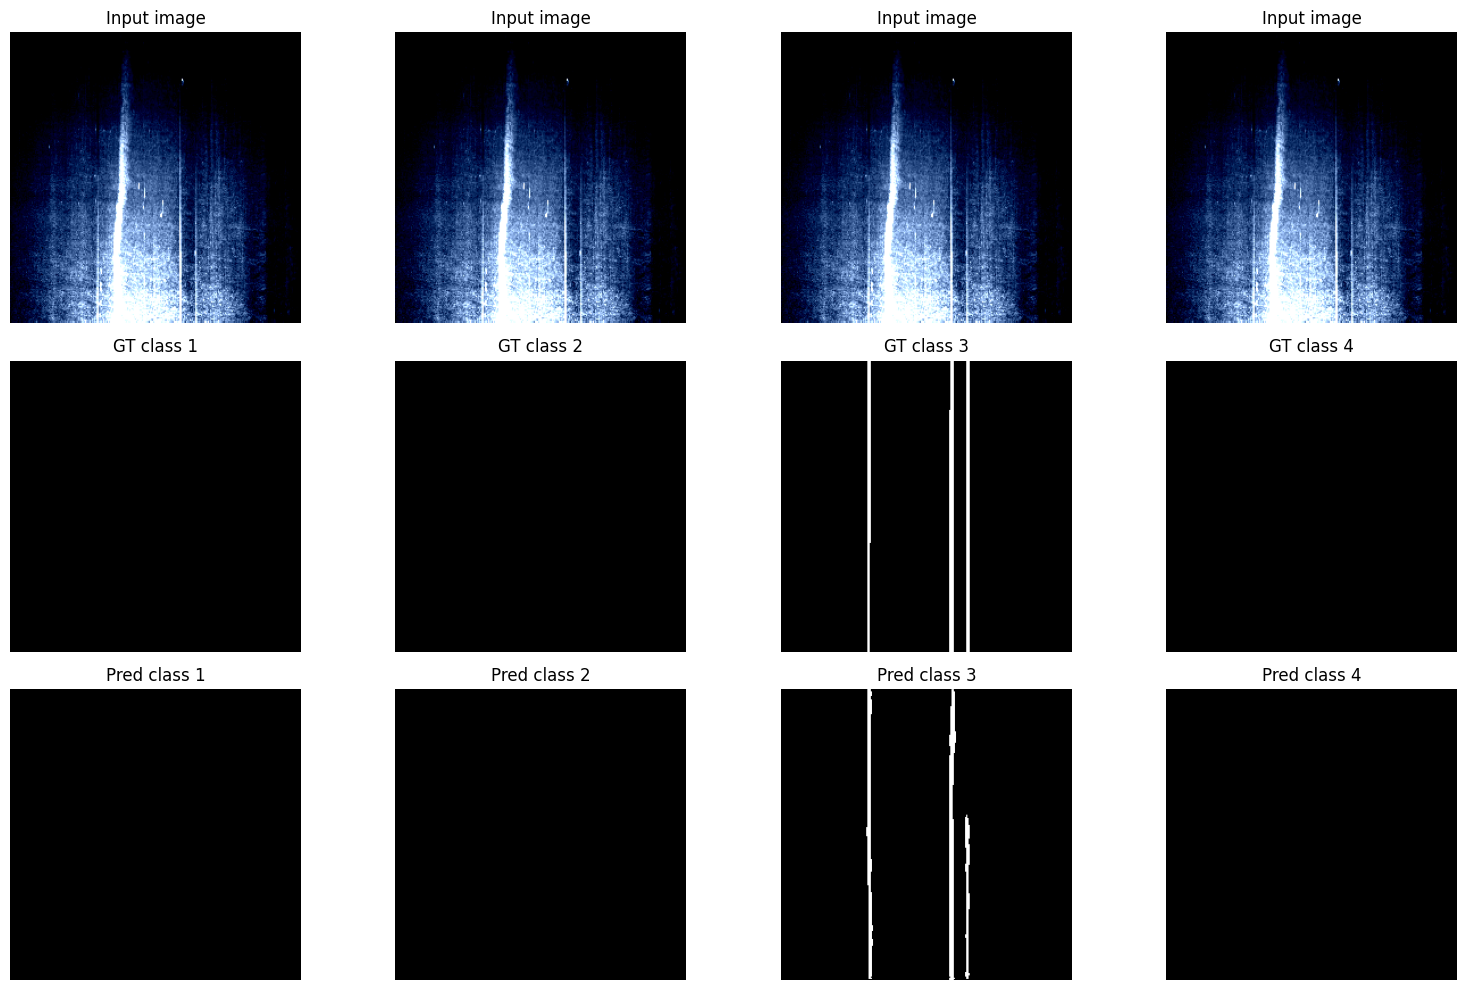

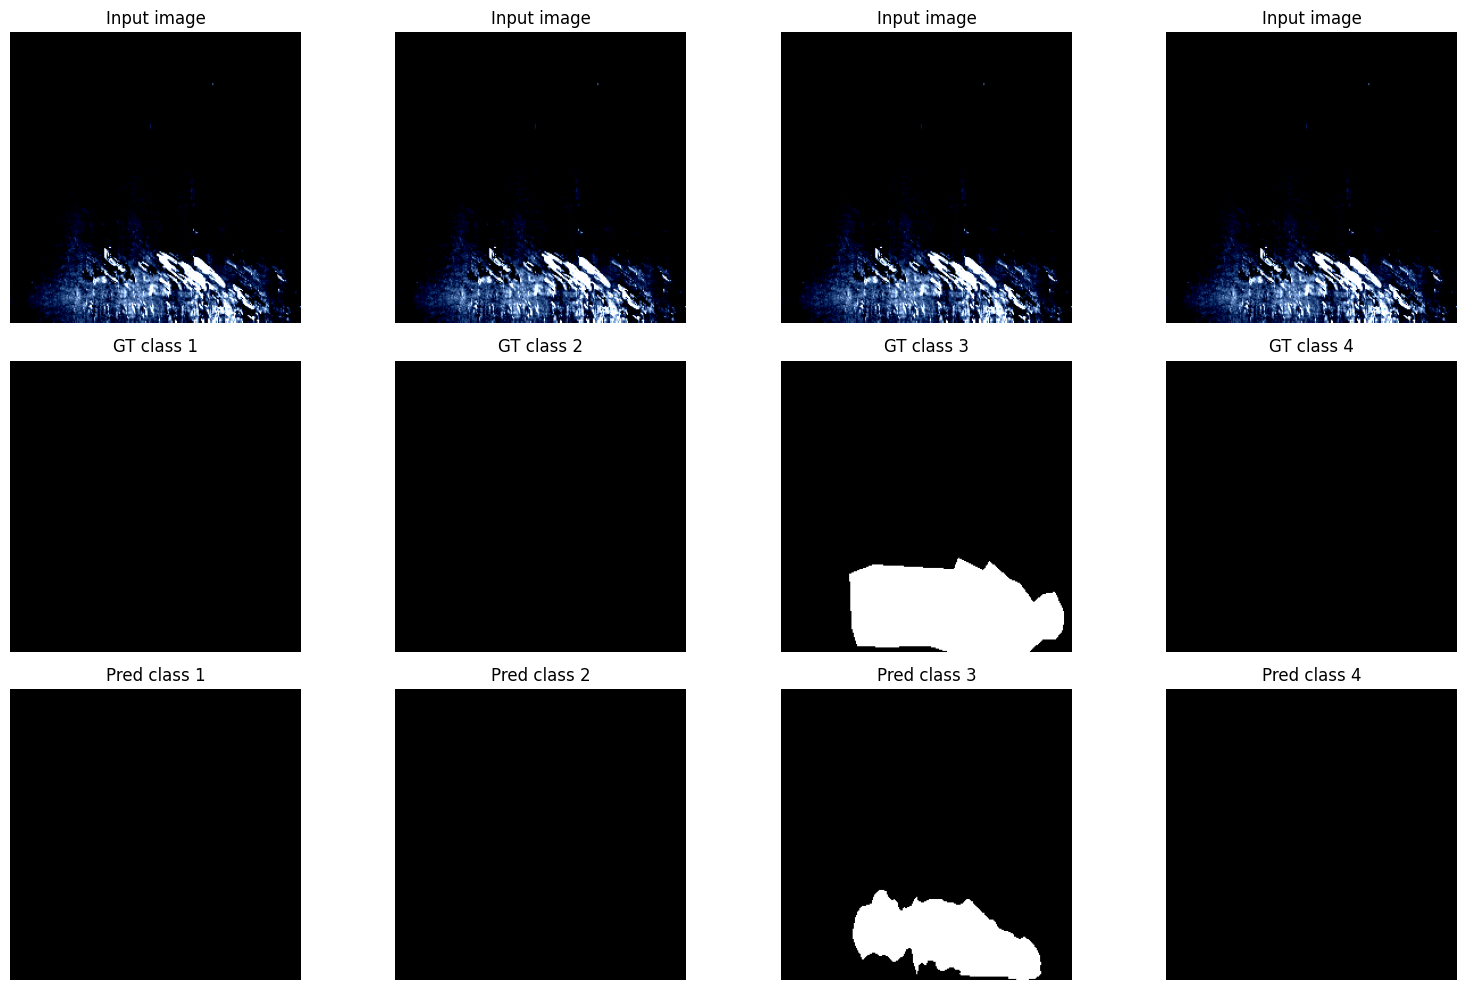

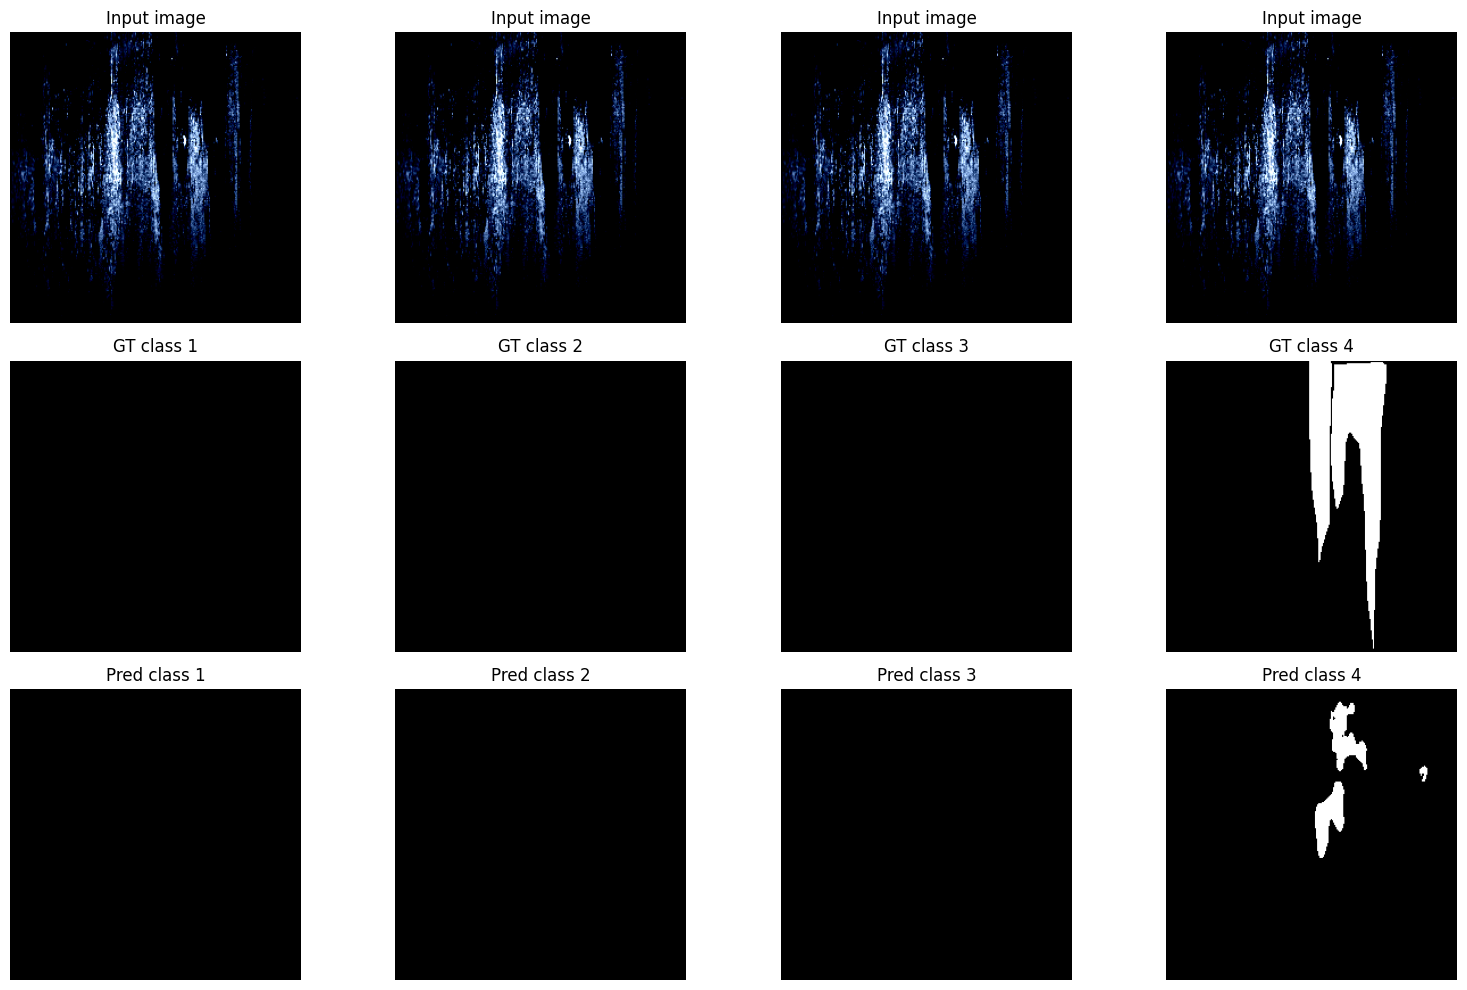

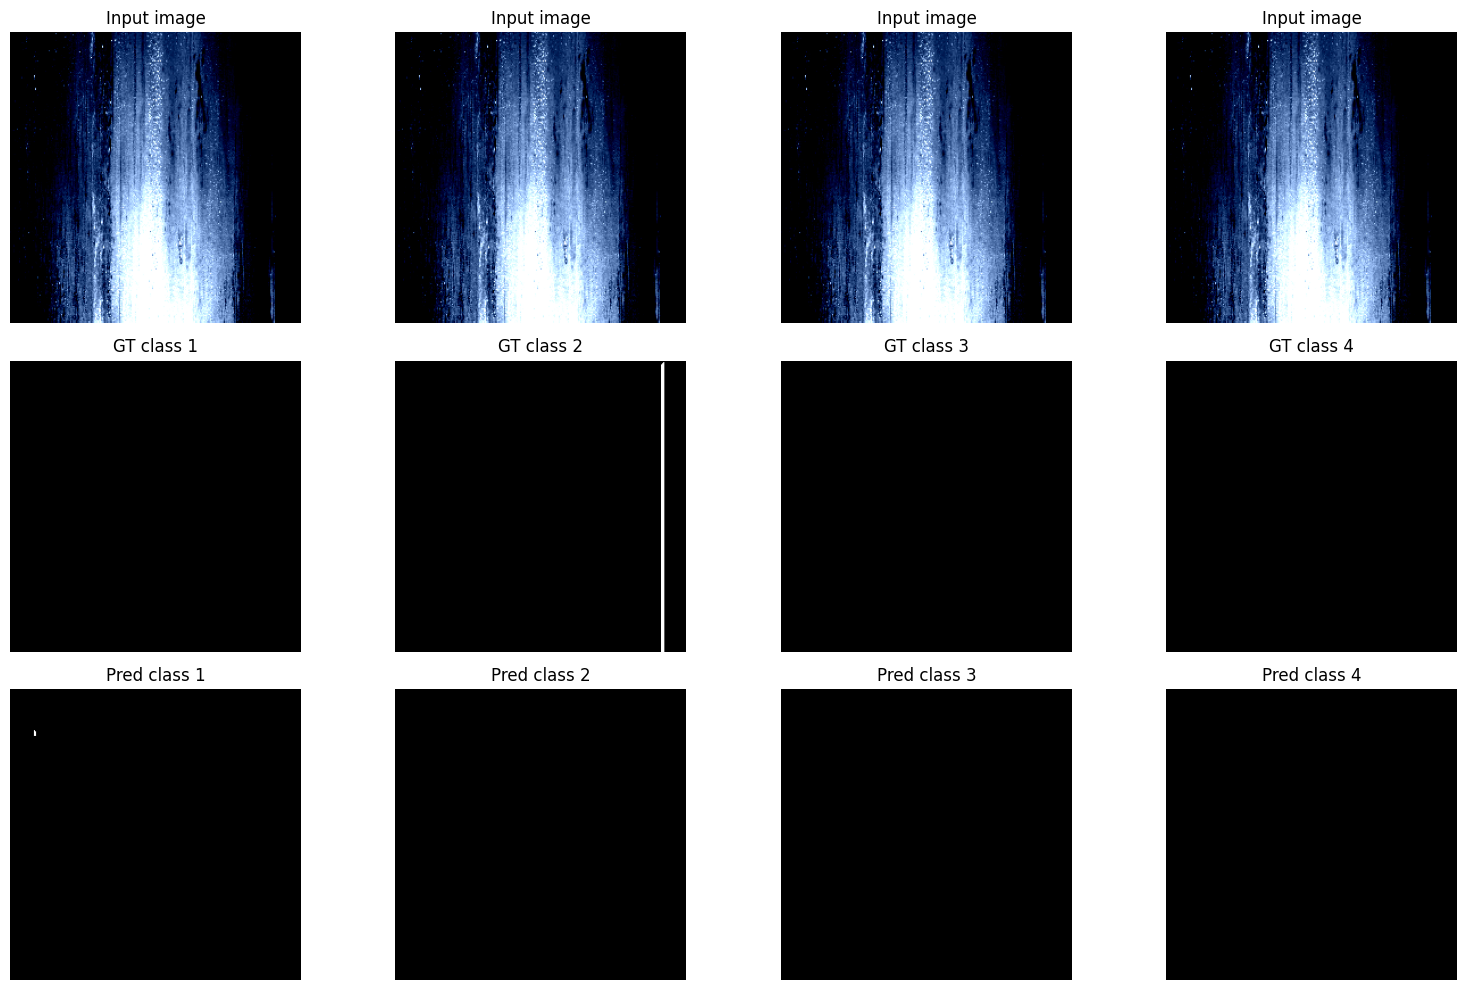

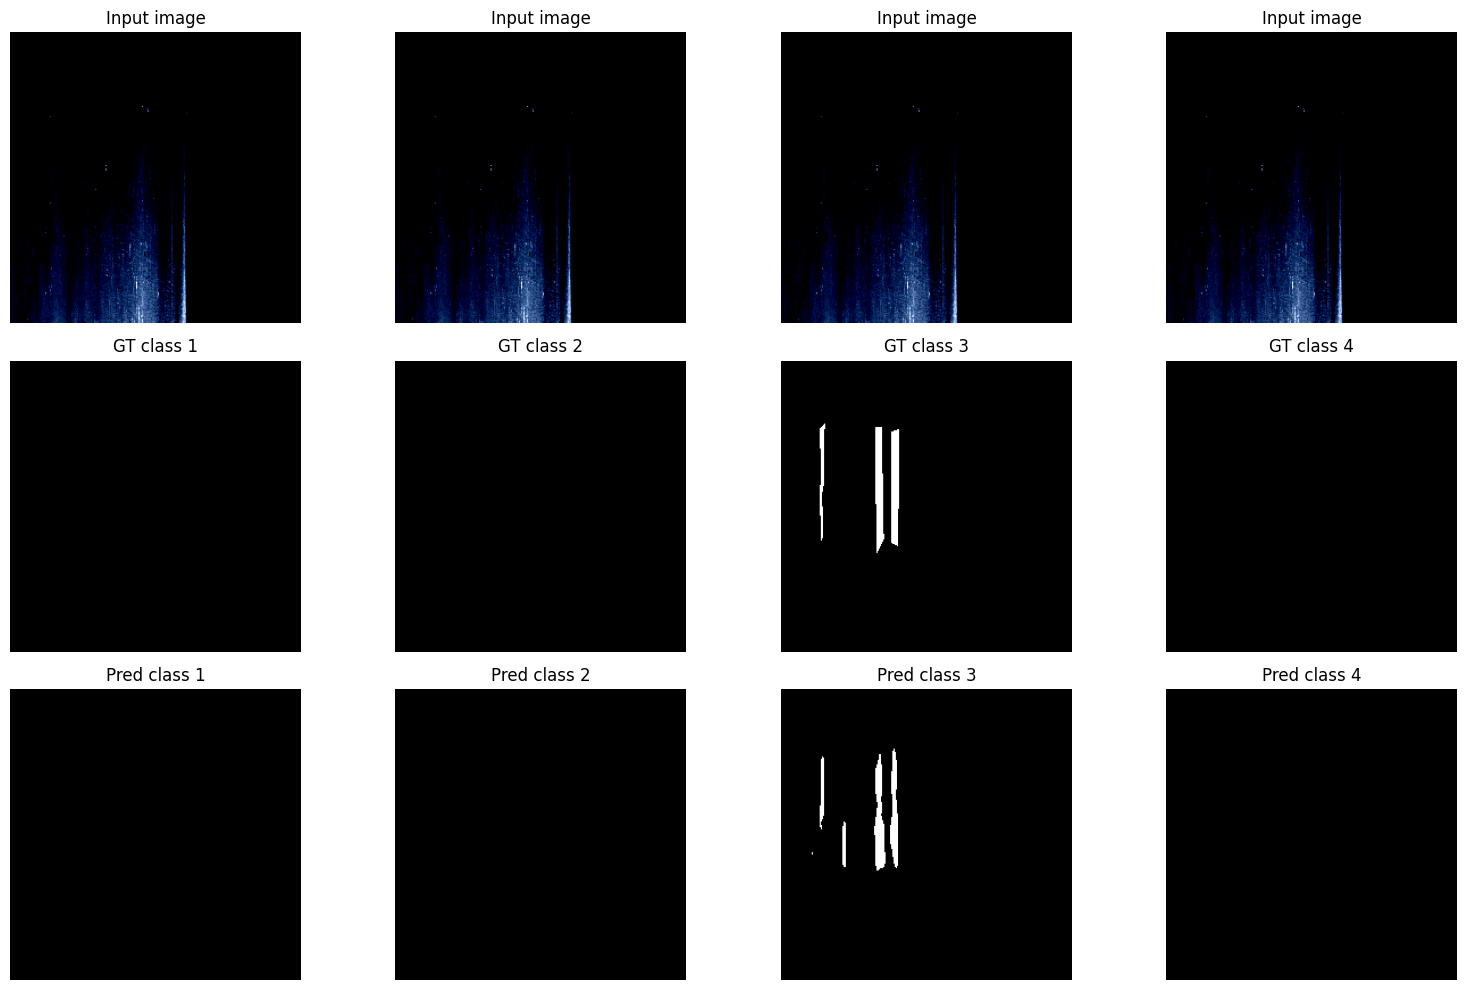

In [23]:
visualize_predictions(
    model=model,
    dataloader=val_loader,
    device=device,
    num_samples=5,
    threshold=0.5
)
